# 08. Batch evaluation of coregistration results

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
from pathlib import Path
import sys

REPO_PATH = Path("/content/drive/MyDrive/geo_projects/llojeta-glacier-analysis/repo")
SRC_PATH = REPO_PATH / "src"

assert REPO_PATH.exists(), f"No existe: {REPO_PATH}"
assert SRC_PATH.exists(), f"No existe: {SRC_PATH}"

if str(SRC_PATH) not in sys.path:
    sys.path.append(str(SRC_PATH))

print("REPO_PATH:", REPO_PATH)
print("SRC_PATH :", SRC_PATH)

REPO_PATH: /content/drive/MyDrive/geo_projects/llojeta-glacier-analysis/repo
SRC_PATH : /content/drive/MyDrive/geo_projects/llojeta-glacier-analysis/repo/src


In [3]:
!pip install xdem geoutils

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.0/208.0 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.3/177.3 kB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 35.8 MB/s eta 0:00:00
  Attempting uninstall: xarray
    Found existing installation: xarray 2025.12.0
    Uninstalling xarray-2025.12.0:
      Successfully uninstalled xarray-2025.12.0


In [4]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import xdem
import geoutils as gu

from projectio.paths import Paths

## Configuración

In [5]:
cfg = Paths(REPO_PATH)

BASE_EPOCH = "2025_B"
MASK_PATH = Path("/content/drive/MyDrive/geo_projects/llojeta-glacier-analysis/Datos_Originales/mascaras/poligono_roca_estable/poligono_roca_estable.shp")

inventory_csv = cfg.qa() / "project_raster_inventory.csv"
coreg_results_csv = REPO_PATH / "outputs" / "coregistration_nk" / "coregistration_nk_results.csv"

EVAL_DIR = REPO_PATH / "outputs" / "coregistration_evaluation_batch"
EVAL_DIR.mkdir(parents=True, exist_ok=True)

assert MASK_PATH.exists(), f"No existe: {MASK_PATH}"
assert inventory_csv.exists(), f"No existe: {inventory_csv}"
assert coreg_results_csv.exists(), f"No existe: {coreg_results_csv}"

print("BASE_EPOCH       :", BASE_EPOCH)
print("MASK_PATH        :", MASK_PATH)
print("inventory_csv    :", inventory_csv)
print("coreg_results_csv:", coreg_results_csv)
print("EVAL_DIR         :", EVAL_DIR)

BASE_EPOCH       : 2025_B
MASK_PATH        : /content/drive/MyDrive/geo_projects/llojeta-glacier-analysis/Datos_Originales/mascaras/poligono_roca_estable/poligono_roca_estable.shp
inventory_csv    : /content/drive/MyDrive/geo_projects/llojeta-glacier-analysis/repo/outputs/qa/project_raster_inventory.csv
coreg_results_csv: /content/drive/MyDrive/geo_projects/llojeta-glacier-analysis/repo/outputs/coregistration_nk/coregistration_nk_results.csv
EVAL_DIR         : /content/drive/MyDrive/geo_projects/llojeta-glacier-analysis/repo/outputs/coregistration_evaluation_batch


## Carga de inventario y resultados

In [6]:
inventory_df = pd.read_csv(inventory_csv)
results_df = pd.read_csv(coreg_results_csv)

print("Inventory rows:", len(inventory_df))
print("Results rows  :", len(results_df))

display(inventory_df.head())
display(results_df.head())

Inventory rows: 12
Results rows  : 5


,filename,epoch,product_type,source_path,path,exists,opened,error,crs,width,...,bounds_top,driver,valid_name,qa_exists,qa_opened,qa_has_crs,qa_has_dimensions,qa_has_bands,qa_valid_name,qa_ok
0,2017_DSM.tif,2017,dsm,/content/drive/MyDrive/geo_projects/llojeta-gl...,/content/drive/MyDrive/geo_projects/llojeta-gl...,True,True,NaN,EPSG:32719,8991,...,8225448.0,GTiff,True,True,True,True,True,True,True,True
1,2017_Ortho.tif,2017,ortho,/content/drive/MyDrive/geo_projects/llojeta-gl...,/content/drive/MyDrive/geo_projects/llojeta-gl...,True,True,NaN,EPSG:32719,8991,...,8225448.0,GTiff,True,True,True,True,True,True,True,True
2,2018_DSM.tif,2018,dsm,/content/drive/MyDrive/geo_projects/llojeta-gl...,/content/drive/MyDrive/geo_projects/llojeta-gl...,True,True,NaN,EPSG:32719,13010,...,8225539.0,GTiff,True,True,True,True,True,True,True,True
3,2018_Ortho.tif,2018,ortho,/content/drive/MyDrive/geo_projects/llojeta-gl...,/content/drive/MyDrive/geo_projects/llojeta-gl...,True,True,NaN,EPSG:32719,13010,...,8225539.0,GTiff,True,True,True,True,True,True,True,True
4,2020_DSM.tif,2020,dsm,/content/drive/MyDrive/geo_projects/llojeta-gl...,/content/drive/MyDrive/geo_projects/llojeta-gl...,True,True,NaN,EPSG:32719,2506,...,8225602.0,GTiff,True,True,True,True,True,True,True,True


,base_dem_path,target_dem_path,mask_vector_path,output_path,factor_giro,poly_order,status,epoch,base_epoch
0,/content/drive/MyDrive/geo_projects/llojeta-gl...,/content/drive/MyDrive/geo_projects/llojeta-gl...,/content/drive/MyDrive/geo_projects/llojeta-gl...,/content/drive/MyDrive/geo_projects/llojeta-gl...,-0.05,1,ok,2017,2025_B
1,/content/drive/MyDrive/geo_projects/llojeta-gl...,/content/drive/MyDrive/geo_projects/llojeta-gl...,/content/drive/MyDrive/geo_projects/llojeta-gl...,/content/drive/MyDrive/geo_projects/llojeta-gl...,-0.05,1,ok,2018,2025_B
2,/content/drive/MyDrive/geo_projects/llojeta-gl...,/content/drive/MyDrive/geo_projects/llojeta-gl...,/content/drive/MyDrive/geo_projects/llojeta-gl...,/content/drive/MyDrive/geo_projects/llojeta-gl...,-0.05,1,ok,2020,2025_B
3,/content/drive/MyDrive/geo_projects/llojeta-gl...,/content/drive/MyDrive/geo_projects/llojeta-gl...,/content/drive/MyDrive/geo_projects/llojeta-gl...,/content/drive/MyDrive/geo_projects/llojeta-gl...,-0.05,1,ok,2023,2025_B
4,/content/drive/MyDrive/geo_projects/llojeta-gl...,/content/drive/MyDrive/geo_projects/llojeta-gl...,/content/drive/MyDrive/geo_projects/llojeta-gl...,/content/drive/MyDrive/geo_projects/llojeta-gl...,-0.05,1,ok,2025_A,2025_B


## Helpers

In [7]:
def get_dsm_path_for_epoch(inventory_df, epoch):
    row = inventory_df[
        (inventory_df["epoch"].astype(str).str.strip() == str(epoch).strip()) &
        (inventory_df["product_type"].astype(str).str.strip().str.lower() == "dsm") &
        (inventory_df["qa_ok"] == True)
    ].copy()

    assert len(row) == 1, f"No se encontró un único DSM válido para epoch={epoch}"
    return Path(row.iloc[0]["source_path"])


def get_corrected_dsm_path(results_df, epoch, base_epoch):
    tmp = results_df.copy()

    tmp["epoch"] = tmp["epoch"].astype(str).str.strip()
    tmp["base_epoch"] = tmp["base_epoch"].astype(str).str.strip()
    tmp["status"] = tmp["status"].astype(str).str.strip()

    row = tmp[
        (tmp["epoch"] == str(epoch).strip()) &
        (tmp["base_epoch"] == str(base_epoch).strip()) &
        (tmp["status"] == "ok")
    ].copy()

    assert len(row) > 0, f"No se encontró ningún DSM corregido para epoch={epoch}, base_epoch={base_epoch}"

    row = row.iloc[-1]
    return Path(row["output_path"])


def clean_dh(values):
    arr = np.asarray(values, dtype="float32")
    arr = arr[np.isfinite(arr)]
    arr = arr[arr != -9999]
    return arr


def nmad(arr):
    arr = np.asarray(arr, dtype="float64")
    arr = arr[np.isfinite(arr)]
    if arr.size == 0:
        return np.nan
    med = np.nanmedian(arr)
    return 1.4826 * np.nanmedian(np.abs(arr - med))


def summarize_stats(arr, label):
    arr = np.asarray(arr, dtype="float64")
    arr = arr[np.isfinite(arr)]

    if arr.size == 0:
        return {
            "label": label,
            "n": 0,
            "mean": np.nan,
            "median": np.nan,
            "std": np.nan,
            "nmad": np.nan,
            "p02": np.nan,
            "p25": np.nan,
            "p75": np.nan,
            "p98": np.nan,
        }

    return {
        "label": label,
        "n": int(arr.size),
        "mean": float(np.nanmean(arr)),
        "median": float(np.nanmedian(arr)),
        "std": float(np.nanstd(arr)),
        "nmad": float(nmad(arr)),
        "p02": float(np.nanpercentile(arr, 2)),
        "p25": float(np.nanpercentile(arr, 25)),
        "p75": float(np.nanpercentile(arr, 75)),
        "p98": float(np.nanpercentile(arr, 98)),
    }


def classify_quality(row):
    if bool(row.get("error", False)):
        return "error"

    median_improved = bool(row["median_improved"])
    nmad_improved = bool(row["nmad_improved"])
    std_improved = bool(row["std_improved"])

    if median_improved and nmad_improved and std_improved:
        return "improved_cleanly"
    elif median_improved and nmad_improved and not std_improved:
        return "improved_robust_but_outliers_remain"
    elif (not median_improved) and (not nmad_improved):
        return "worsened"
    else:
        return "mixed"

## Resolver DEM base y máscara estable

In [8]:
BASE_DEM_PATH = get_dsm_path_for_epoch(inventory_df, BASE_EPOCH)
assert BASE_DEM_PATH.exists(), f"No existe: {BASE_DEM_PATH}"

base_dem = xdem.DEM(BASE_DEM_PATH)
mask_vector = gu.Vector(MASK_PATH)
stable_mask = mask_vector.create_mask(base_dem)

print("BASE_DEM_PATH:", BASE_DEM_PATH)
print("Base shape   :", base_dem.shape)
print("Base res     :", base_dem.res)
print("Base crs     :", base_dem.crs)
print("Stable pixels:", int(np.sum(stable_mask)))

BASE_DEM_PATH: /content/drive/MyDrive/geo_projects/llojeta-glacier-analysis/repo/data/raw/llojeta/2025_B/dsm/2025_B_DSM.tif
Base shape   : (2172, 2588)
Base res     : (0.5, 0.5)
Base crs     : EPSG:32719
Stable pixels: 387091


## Selección de epochs evaluables desde resultados de coregistro

In [9]:
tmp = results_df.copy()
tmp["epoch"] = tmp["epoch"].astype(str).str.strip()
tmp["base_epoch"] = tmp["base_epoch"].astype(str).str.strip()
tmp["status"] = tmp["status"].astype(str).str.strip()

ok_rows = tmp[
    (tmp["base_epoch"] == BASE_EPOCH) &
    (tmp["status"] == "ok")
].copy()

assert len(ok_rows) > 0, "No hay filas OK para el base_epoch seleccionado"

ok_rows = ok_rows.sort_values(["epoch"]).reset_index(drop=True)

print("Epochs a evaluar:")
display(ok_rows[["epoch", "base_epoch", "output_path", "factor_giro", "poly_order", "status"]])

Epochs a evaluar:


,epoch,base_epoch,output_path,factor_giro,poly_order,status
0,2017,2025_B,/content/drive/MyDrive/geo_projects/llojeta-gl...,-0.05,1,ok
1,2018,2025_B,/content/drive/MyDrive/geo_projects/llojeta-gl...,-0.05,1,ok
2,2020,2025_B,/content/drive/MyDrive/geo_projects/llojeta-gl...,-0.05,1,ok
3,2023,2025_B,/content/drive/MyDrive/geo_projects/llojeta-gl...,-0.05,1,ok
4,2025_A,2025_B,/content/drive/MyDrive/geo_projects/llojeta-gl...,-0.05,1,ok


## Evaluación batch

In [10]:
stats_records = []
comparison_records = []
error_records = []

for _, row in ok_rows.iterrows():
    epoch = str(row["epoch"]).strip()
    corr_path = Path(row["output_path"])

    print(f"\n[{epoch}] =====================================")
    print("Corrected:", corr_path)

    try:
        target_orig_path = get_dsm_path_for_epoch(inventory_df, epoch)

        assert target_orig_path.exists(), f"No existe target original: {target_orig_path}"
        assert corr_path.exists(), f"No existe target corregido: {corr_path}"

        target_orig = xdem.DEM(target_orig_path)
        target_corr = xdem.DEM(corr_path)

        target_orig_on_base = target_orig.reproject(base_dem)
        target_corr_on_base = target_corr.reproject(base_dem)

        dh_before = target_orig_on_base - base_dem
        dh_after = target_corr_on_base - base_dem

        before_vals = np.array(dh_before.data, dtype="float32")
        after_vals = np.array(dh_after.data, dtype="float32")
        mask_bool = np.array(stable_mask, dtype=bool)

        before_stable = clean_dh(before_vals[mask_bool])
        after_stable = clean_dh(after_vals[mask_bool])

        stats_before = summarize_stats(before_stable, "before_coreg")
        stats_after = summarize_stats(after_stable, "after_coreg")

        stats_records.append({
            "target_epoch": epoch,
            "base_epoch": BASE_EPOCH,
            **stats_before,
        })
        stats_records.append({
            "target_epoch": epoch,
            "base_epoch": BASE_EPOCH,
            **stats_after,
        })

        comparison = {
            "target_epoch": epoch,
            "base_epoch": BASE_EPOCH,
            "target_orig_path": str(target_orig_path),
            "target_corr_path": str(corr_path),
            "factor_giro": row.get("factor_giro", np.nan),
            "poly_order": row.get("poly_order", np.nan),
            "n_before": stats_before["n"],
            "n_after": stats_after["n"],
            "mean_before": stats_before["mean"],
            "mean_after": stats_after["mean"],
            "median_before": stats_before["median"],
            "median_after": stats_after["median"],
            "std_before": stats_before["std"],
            "std_after": stats_after["std"],
            "nmad_before": stats_before["nmad"],
            "nmad_after": stats_after["nmad"],
            "mean_abs_before": abs(stats_before["mean"]),
            "mean_abs_after": abs(stats_after["mean"]),
            "median_abs_before": abs(stats_before["median"]),
            "median_abs_after": abs(stats_after["median"]),
            "mean_improved": abs(stats_after["mean"]) < abs(stats_before["mean"]),
            "median_improved": abs(stats_after["median"]) < abs(stats_before["median"]),
            "std_improved": stats_after["std"] < stats_before["std"],
            "nmad_improved": stats_after["nmad"] < stats_before["nmad"],
            "error": False,
        }

        comparison["quality_flag"] = classify_quality(comparison)
        comparison_records.append(comparison)

        print("N before/after     :", stats_before["n"], stats_after["n"])
        print("Median before/after:", stats_before["median"], stats_after["median"])
        print("STD before/after   :", stats_before["std"], stats_after["std"])
        print("NMAD before/after  :", stats_before["nmad"], stats_after["nmad"])
        print("quality_flag       :", comparison["quality_flag"])

    except Exception as e:
        print("ERROR:", e)

        error_records.append({
            "target_epoch": epoch,
            "base_epoch": BASE_EPOCH,
            "target_corr_path": str(corr_path),
            "error": str(e),
        })

        comparison_records.append({
            "target_epoch": epoch,
            "base_epoch": BASE_EPOCH,
            "target_orig_path": None,
            "target_corr_path": str(corr_path),
            "factor_giro": row.get("factor_giro", np.nan),
            "poly_order": row.get("poly_order", np.nan),
            "n_before": np.nan,
            "n_after": np.nan,
            "mean_before": np.nan,
            "mean_after": np.nan,
            "median_before": np.nan,
            "median_after": np.nan,
            "std_before": np.nan,
            "std_after": np.nan,
            "nmad_before": np.nan,
            "nmad_after": np.nan,
            "mean_abs_before": np.nan,
            "mean_abs_after": np.nan,
            "median_abs_before": np.nan,
            "median_abs_after": np.nan,
            "mean_improved": False,
            "median_improved": False,
            "std_improved": False,
            "nmad_improved": False,
            "quality_flag": "error",
            "error": True,
            "error_message": str(e),
        })


[2017] =====================================
Corrected: /content/drive/MyDrive/geo_projects/llojeta-glacier-analysis/repo/outputs/coregistration_nk/2017_DSM_nk_corrected.tif
N before/after     : 1787617 1786630
Median before/after: 3.61669921875 1.1572265625
STD before/after   : 419.9449759705742 426.36473671666755
NMAD before/after  : 4.586069824218749 3.74631591796875
quality_flag       : improved_robust_but_outliers_remain

[2018] =====================================
Corrected: /content/drive/MyDrive/geo_projects/llojeta-glacier-analysis/repo/outputs/coregistration_nk/2018_DSM_nk_corrected.tif
N before/after     : 3507520 3502947
Median before/after: 6.86328125 0.20703125
STD before/after   : 2272.8632366215797 2281.316104982452
NMAD before/after  : 8.730544921875 9.74186923828125
quality_flag       : mixed

[2020] =====================================
Corrected: /content/drive/MyDrive/geo_projects/llojeta-glacier-analysis/repo/outputs/coregistration_nk/2020_DSM_nk_corrected.tif
N

## Tablas finales

In [11]:
stats_df = pd.DataFrame(stats_records)
comparison_df = pd.DataFrame(comparison_records)
errors_df = pd.DataFrame(error_records)

print("stats_df rows     :", len(stats_df))
print("comparison_df rows:", len(comparison_df))
print("errors_df rows    :", len(errors_df))

display(stats_df)
display(comparison_df)
if len(errors_df) > 0:
    display(errors_df)

stats_df rows     : 10
comparison_df rows: 5
errors_df rows    : 0


,target_epoch,base_epoch,label,n,mean,median,std,nmad,p02,p25,p75,p98
0,2017,2025_B,before_coreg,1787617,40.044352,3.616699,419.944976,4.586070,-2.699707,1.586914,9.815430,19.119629
1,2017,2025_B,after_coreg,1786630,38.918251,1.157227,426.364737,3.746316,-4.176758,-0.363770,7.398438,16.817100
2,2018,2025_B,before_coreg,3507520,1412.587335,6.863281,2272.863237,8.730545,-1.898926,2.452148,4998.001953,5194.951172
3,2018,2025_B,after_coreg,3502947,1420.177612,0.207031,2281.316105,9.741869,-10.617676,-4.305664,4997.076904,5192.385293
4,2020,2025_B,before_coreg,4116129,1626.154481,6.287109,2347.964656,14.356896,-8.349609,-0.174316,4974.315430,5115.879883
5,2020,2025_B,after_coreg,4107211,1630.960780,2.517090,2351.180689,12.504370,-10.552637,-2.529297,4972.837402,5116.479980
6,2023,2025_B,before_coreg,2594219,700.476374,0.179199,1751.925187,0.508920,-0.624023,-0.012207,4.743652,5149.749512
7,2023,2025_B,after_coreg,2594219,700.457403,0.163086,1751.927836,0.509644,-0.640137,-0.029297,4.713379,5149.742148
8,2025_A,2025_B,before_coreg,2458740,501.763221,0.038086,1531.393737,0.131031,-0.376572,-0.012207,0.351074,5207.513184
9,2025_A,2025_B,after_coreg,2458740,501.774675,0.049316,1531.393898,0.131754,-0.364258,-0.001465,0.363281,5207.525605


,target_epoch,base_epoch,target_orig_path,target_corr_path,factor_giro,poly_order,n_before,n_after,mean_before,mean_after,...,mean_abs_before,mean_abs_after,median_abs_before,median_abs_after,mean_improved,median_improved,std_improved,nmad_improved,error,quality_flag
0,2017,2025_B,/content/drive/MyDrive/geo_projects/llojeta-gl...,/content/drive/MyDrive/geo_projects/llojeta-gl...,-0.05,1,1787617,1786630,40.044352,38.918251,...,40.044352,38.918251,3.616699,1.157227,True,True,False,True,False,improved_robust_but_outliers_remain
1,2018,2025_B,/content/drive/MyDrive/geo_projects/llojeta-gl...,/content/drive/MyDrive/geo_projects/llojeta-gl...,-0.05,1,3507520,3502947,1412.587335,1420.177612,...,1412.587335,1420.177612,6.863281,0.207031,False,True,False,False,False,mixed
2,2020,2025_B,/content/drive/MyDrive/geo_projects/llojeta-gl...,/content/drive/MyDrive/geo_projects/llojeta-gl...,-0.05,1,4116129,4107211,1626.154481,1630.960780,...,1626.154481,1630.960780,6.287109,2.517090,False,True,False,True,False,improved_robust_but_outliers_remain
3,2023,2025_B,/content/drive/MyDrive/geo_projects/llojeta-gl...,/content/drive/MyDrive/geo_projects/llojeta-gl...,-0.05,1,2594219,2594219,700.476374,700.457403,...,700.476374,700.457403,0.179199,0.163086,True,True,False,False,False,mixed
4,2025_A,2025_B,/content/drive/MyDrive/geo_projects/llojeta-gl...,/content/drive/MyDrive/geo_projects/llojeta-gl...,-0.05,1,2458740,2458740,501.763221,501.774675,...,501.763221,501.774675,0.038086,0.049316,False,False,False,False,False,worsened


## Resumen agregado

In [12]:
ok_comp = comparison_df[comparison_df["quality_flag"] != "error"].copy()

summary = {
    "base_epoch": BASE_EPOCH,
    "epochs_total_in_results": int(len(ok_rows)),
    "epochs_evaluated_ok": int(len(ok_comp)),
    "epochs_with_error": int((comparison_df["quality_flag"] == "error").sum()),
    "improved_mean_count": int(ok_comp["mean_improved"].sum()) if len(ok_comp) else 0,
    "improved_median_count": int(ok_comp["median_improved"].sum()) if len(ok_comp) else 0,
    "improved_std_count": int(ok_comp["std_improved"].sum()) if len(ok_comp) else 0,
    "improved_nmad_count": int(ok_comp["nmad_improved"].sum()) if len(ok_comp) else 0,
    "quality_flag_counts": comparison_df["quality_flag"].value_counts(dropna=False).to_dict(),
}

summary

{'base_epoch': '2025_B',
 'epochs_total_in_results': 5,
 'epochs_evaluated_ok': 5,
 'epochs_with_error': 0,
 'improved_mean_count': 2,
 'improved_median_count': 4,
 'improved_std_count': 0,
 'improved_nmad_count': 2,
 'quality_flag_counts': {'improved_robust_but_outliers_remain': 2,
  'mixed': 2,
  'worsened': 1}}

## Ranking por desempeño posterior

In [13]:
if len(ok_comp) > 0:
    ranked_df = ok_comp.sort_values(
        by=["nmad_after", "median_abs_after", "mean_abs_after"],
        ascending=[True, True, True]
    ).reset_index(drop=True)
else:
    ranked_df = ok_comp.copy()

display(ranked_df)

,target_epoch,base_epoch,target_orig_path,target_corr_path,factor_giro,poly_order,n_before,n_after,mean_before,mean_after,...,mean_abs_before,mean_abs_after,median_abs_before,median_abs_after,mean_improved,median_improved,std_improved,nmad_improved,error,quality_flag
0,2025_A,2025_B,/content/drive/MyDrive/geo_projects/llojeta-gl...,/content/drive/MyDrive/geo_projects/llojeta-gl...,-0.05,1,2458740,2458740,501.763221,501.774675,...,501.763221,501.774675,0.038086,0.049316,False,False,False,False,False,worsened
1,2023,2025_B,/content/drive/MyDrive/geo_projects/llojeta-gl...,/content/drive/MyDrive/geo_projects/llojeta-gl...,-0.05,1,2594219,2594219,700.476374,700.457403,...,700.476374,700.457403,0.179199,0.163086,True,True,False,False,False,mixed
2,2017,2025_B,/content/drive/MyDrive/geo_projects/llojeta-gl...,/content/drive/MyDrive/geo_projects/llojeta-gl...,-0.05,1,1787617,1786630,40.044352,38.918251,...,40.044352,38.918251,3.616699,1.157227,True,True,False,True,False,improved_robust_but_outliers_remain
3,2018,2025_B,/content/drive/MyDrive/geo_projects/llojeta-gl...,/content/drive/MyDrive/geo_projects/llojeta-gl...,-0.05,1,3507520,3502947,1412.587335,1420.177612,...,1412.587335,1420.177612,6.863281,0.207031,False,True,False,False,False,mixed
4,2020,2025_B,/content/drive/MyDrive/geo_projects/llojeta-gl...,/content/drive/MyDrive/geo_projects/llojeta-gl...,-0.05,1,4116129,4107211,1626.154481,1630.960780,...,1626.154481,1630.960780,6.287109,2.517090,False,True,False,True,False,improved_robust_but_outliers_remain


## Gráficas resumen

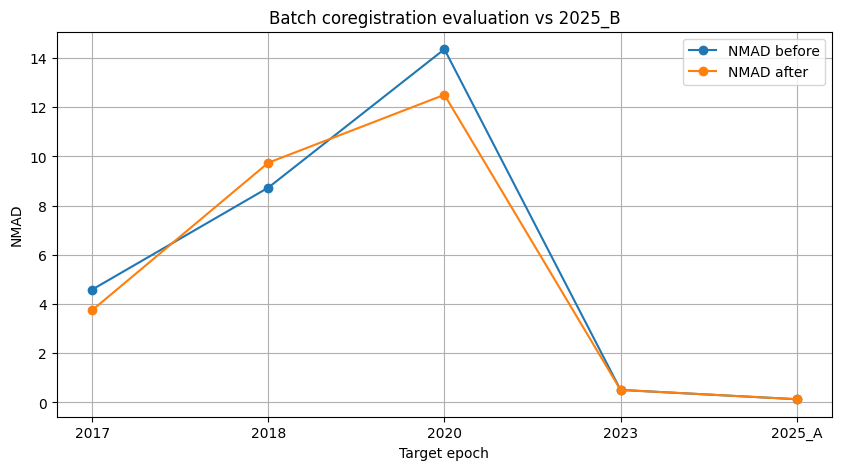

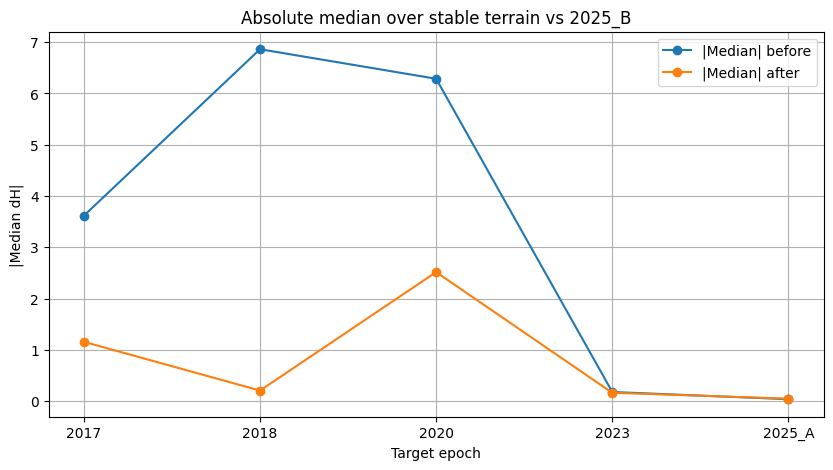

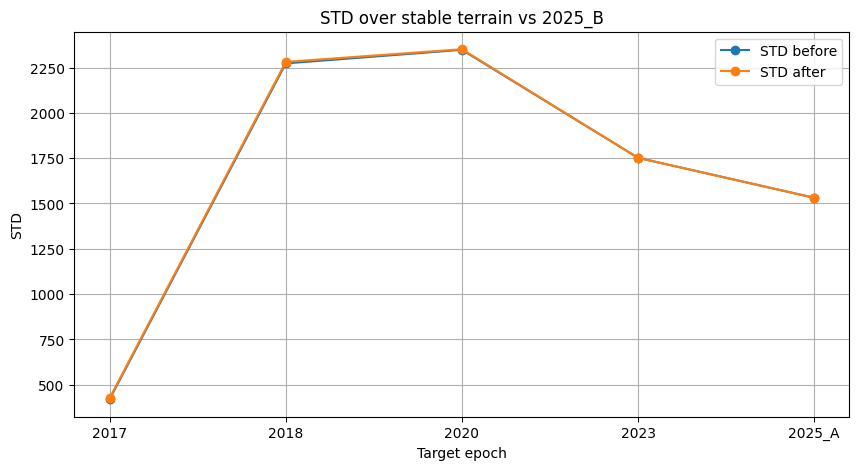

In [14]:
if len(ok_comp) > 0:
    plot_df = ok_comp.sort_values("target_epoch").copy()

    plt.figure(figsize=(10, 5))
    plt.plot(plot_df["target_epoch"], plot_df["nmad_before"], marker="o", label="NMAD before")
    plt.plot(plot_df["target_epoch"], plot_df["nmad_after"], marker="o", label="NMAD after")
    plt.xlabel("Target epoch")
    plt.ylabel("NMAD")
    plt.title(f"Batch coregistration evaluation vs {BASE_EPOCH}")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(10, 5))
    plt.plot(plot_df["target_epoch"], plot_df["median_abs_before"], marker="o", label="|Median| before")
    plt.plot(plot_df["target_epoch"], plot_df["median_abs_after"], marker="o", label="|Median| after")
    plt.xlabel("Target epoch")
    plt.ylabel("|Median dH|")
    plt.title(f"Absolute median over stable terrain vs {BASE_EPOCH}")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(10, 5))
    plt.plot(plot_df["target_epoch"], plot_df["std_before"], marker="o", label="STD before")
    plt.plot(plot_df["target_epoch"], plot_df["std_after"], marker="o", label="STD after")
    plt.xlabel("Target epoch")
    plt.ylabel("STD")
    plt.title(f"STD over stable terrain vs {BASE_EPOCH}")
    plt.legend()
    plt.grid(True)
    plt.show()

## Exportación

In [15]:
stats_csv = EVAL_DIR / "coreg_batch_stats_long.csv"
comparison_csv = EVAL_DIR / "coreg_batch_comparison.csv"
ranked_csv = EVAL_DIR / "coreg_batch_ranked.csv"
summary_json = EVAL_DIR / "coreg_batch_summary.json"
errors_csv = EVAL_DIR / "coreg_batch_errors.csv"

stats_df.to_csv(stats_csv, index=False, encoding="utf-8")
comparison_df.to_csv(comparison_csv, index=False, encoding="utf-8")
ranked_df.to_csv(ranked_csv, index=False, encoding="utf-8")
errors_df.to_csv(errors_csv, index=False, encoding="utf-8")

with open(summary_json, "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2, ensure_ascii=False)

print("Guardado:", stats_csv)
print("Guardado:", comparison_csv)
print("Guardado:", ranked_csv)
print("Guardado:", errors_csv)
print("Guardado:", summary_json)

Guardado: /content/drive/MyDrive/geo_projects/llojeta-glacier-analysis/repo/outputs/coregistration_evaluation_batch/coreg_batch_stats_long.csv
Guardado: /content/drive/MyDrive/geo_projects/llojeta-glacier-analysis/repo/outputs/coregistration_evaluation_batch/coreg_batch_comparison.csv
Guardado: /content/drive/MyDrive/geo_projects/llojeta-glacier-analysis/repo/outputs/coregistration_evaluation_batch/coreg_batch_ranked.csv
Guardado: /content/drive/MyDrive/geo_projects/llojeta-glacier-analysis/repo/outputs/coregistration_evaluation_batch/coreg_batch_errors.csv
Guardado: /content/drive/MyDrive/geo_projects/llojeta-glacier-analysis/repo/outputs/coregistration_evaluation_batch/coreg_batch_summary.json


## Resumen final

In [16]:
print("=== RESUMEN FINAL ===")
print("BASE_EPOCH           :", BASE_EPOCH)
print("Epochs en results OK :", len(ok_rows))
print("Evaluados sin error  :", summary["epochs_evaluated_ok"])
print("Con error            :", summary["epochs_with_error"])
print("Improved mean count  :", summary["improved_mean_count"])
print("Improved median count:", summary["improved_median_count"])
print("Improved std count   :", summary["improved_std_count"])
print("Improved nmad count  :", summary["improved_nmad_count"])
print("Quality flags        :", summary["quality_flag_counts"])

print("\nComparison:")
display(comparison_df)

print("\nRanking:")
display(ranked_df)

if len(errors_df) > 0:
    print("\nErrores:")
    display(errors_df)

=== RESUMEN FINAL ===
BASE_EPOCH           : 2025_B
Epochs en results OK : 5
Evaluados sin error  : 5
Con error            : 0
Improved mean count  : 2
Improved median count: 4
Improved std count   : 0
Improved nmad count  : 2
Quality flags        : {'improved_robust_but_outliers_remain': 2, 'mixed': 2, 'worsened': 1}

Comparison:


,target_epoch,base_epoch,target_orig_path,target_corr_path,factor_giro,poly_order,n_before,n_after,mean_before,mean_after,...,mean_abs_before,mean_abs_after,median_abs_before,median_abs_after,mean_improved,median_improved,std_improved,nmad_improved,error,quality_flag
0,2017,2025_B,/content/drive/MyDrive/geo_projects/llojeta-gl...,/content/drive/MyDrive/geo_projects/llojeta-gl...,-0.05,1,1787617,1786630,40.044352,38.918251,...,40.044352,38.918251,3.616699,1.157227,True,True,False,True,False,improved_robust_but_outliers_remain
1,2018,2025_B,/content/drive/MyDrive/geo_projects/llojeta-gl...,/content/drive/MyDrive/geo_projects/llojeta-gl...,-0.05,1,3507520,3502947,1412.587335,1420.177612,...,1412.587335,1420.177612,6.863281,0.207031,False,True,False,False,False,mixed
2,2020,2025_B,/content/drive/MyDrive/geo_projects/llojeta-gl...,/content/drive/MyDrive/geo_projects/llojeta-gl...,-0.05,1,4116129,4107211,1626.154481,1630.960780,...,1626.154481,1630.960780,6.287109,2.517090,False,True,False,True,False,improved_robust_but_outliers_remain
3,2023,2025_B,/content/drive/MyDrive/geo_projects/llojeta-gl...,/content/drive/MyDrive/geo_projects/llojeta-gl...,-0.05,1,2594219,2594219,700.476374,700.457403,...,700.476374,700.457403,0.179199,0.163086,True,True,False,False,False,mixed
4,2025_A,2025_B,/content/drive/MyDrive/geo_projects/llojeta-gl...,/content/drive/MyDrive/geo_projects/llojeta-gl...,-0.05,1,2458740,2458740,501.763221,501.774675,...,501.763221,501.774675,0.038086,0.049316,False,False,False,False,False,worsened



Ranking:


,target_epoch,base_epoch,target_orig_path,target_corr_path,factor_giro,poly_order,n_before,n_after,mean_before,mean_after,...,mean_abs_before,mean_abs_after,median_abs_before,median_abs_after,mean_improved,median_improved,std_improved,nmad_improved,error,quality_flag
0,2025_A,2025_B,/content/drive/MyDrive/geo_projects/llojeta-gl...,/content/drive/MyDrive/geo_projects/llojeta-gl...,-0.05,1,2458740,2458740,501.763221,501.774675,...,501.763221,501.774675,0.038086,0.049316,False,False,False,False,False,worsened
1,2023,2025_B,/content/drive/MyDrive/geo_projects/llojeta-gl...,/content/drive/MyDrive/geo_projects/llojeta-gl...,-0.05,1,2594219,2594219,700.476374,700.457403,...,700.476374,700.457403,0.179199,0.163086,True,True,False,False,False,mixed
2,2017,2025_B,/content/drive/MyDrive/geo_projects/llojeta-gl...,/content/drive/MyDrive/geo_projects/llojeta-gl...,-0.05,1,1787617,1786630,40.044352,38.918251,...,40.044352,38.918251,3.616699,1.157227,True,True,False,True,False,improved_robust_but_outliers_remain
3,2018,2025_B,/content/drive/MyDrive/geo_projects/llojeta-gl...,/content/drive/MyDrive/geo_projects/llojeta-gl...,-0.05,1,3507520,3502947,1412.587335,1420.177612,...,1412.587335,1420.177612,6.863281,0.207031,False,True,False,False,False,mixed
4,2020,2025_B,/content/drive/MyDrive/geo_projects/llojeta-gl...,/content/drive/MyDrive/geo_projects/llojeta-gl...,-0.05,1,4116129,4107211,1626.154481,1630.960780,...,1626.154481,1630.960780,6.287109,2.517090,False,True,False,True,False,improved_robust_but_outliers_remain
